# Task 4: Trend Analysis by Release Year
**Objective:** Analyze how Netflix content production has changed over time
## Step 1: Organize content by release year
Loaded the cleaned dataset and checked the range and quality of `release_year`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/netflix_cleaned.csv", parse_dates=["date_added"])

print("Total titles:", len(df))
print("Release years:", df["release_year"].min(), "to", df["release_year"].max())
print("Distinct years:", df["release_year"].nunique())
print("Missing release_year:", df["release_year"].isnull().sum())

# Share of catalogue by era
print("\nReleased before 2000:", (df["release_year"] < 2000).sum())
print(f"Released 2010 or later: {(df['release_year'] >= 2010).mean():.1%}")

Total titles: 8786
Release years: 1925 to 2021
Distinct years: 74
Missing release_year: 0

Released before 2000: 525
Released 2010 or later: 84.8%


## Step 2: Calculate yearly content releases
Counted titles per release year, in total and split by Movie vs TV Show

In [2]:
#titles per release year
yearly = df.groupby(["release_year", "type"]).size().unstack(fill_value=0)
yearly["Total"] = yearly["Movie"] + yearly["TV Show"]

#peak year and the most recent years
peak_year = yearly["Total"].idxmax()
print(f"Peak release year: {peak_year} ({yearly.loc[peak_year, 'Total']:,} titles)\n")

yearly.loc[2010:2021]

Peak release year: 2018 (1,144 titles)



type,Movie,TV Show,Total
release_year,,,
2010,153,39,192
2011,145,40,185
2012,173,63,236
2013,225,61,286
2014,263,88,351
2015,396,159,555
2016,658,243,901
2017,765,265,1030
2018,766,378,1144


## Step 3: Identify growth and decline trends
Calculated year-over-year growth, the peak and decline for Movies vs TV Shows, and the TV Show share over time. 
Focused on 2010–2021, where 85% of titles sit

In [3]:
trend = yearly.loc[2010:2021].copy()

#year-over-year growth
trend["Total_YoY_%"] = trend["Total"].pct_change().mul(100).round(1)
trend["Movie_YoY_%"] = trend["Movie"].pct_change().mul(100).round(1)
trend["TV_YoY_%"] = trend["TV Show"].pct_change().mul(100).round(1)

#TV Show share of each year's releases
trend["TV_share_%"] = (trend["TV Show"] / trend["Total"] * 100).round(1)

display(trend[["Total", "Total_YoY_%", "Movie_YoY_%", "TV_YoY_%", "TV_share_%"]])

#key comparisons
def change(a, b, col):
    return (trend.loc[b, col] / trend.loc[a, col] - 1) * 100

print(f"Growth 2015 -> 2018 (total):   {change(2015, 2018, 'Total'):+.1f}%")
print(f"Change 2018 -> 2020 (total):   {change(2018, 2020, 'Total'):+.1f}%")
print(f"Change 2018 -> 2020 (Movies):  {change(2018, 2020, 'Movie'):+.1f}%")
print(f"Change 2018 -> 2020 (TV Shows): {change(2018, 2020, 'TV Show'):+.1f}%")

type,Total,Total_YoY_%,Movie_YoY_%,TV_YoY_%,TV_share_%
release_year,,,,,
2010,192,NaN,NaN,NaN,20.3
2011,185,-3.6,-5.2,2.6,21.6
2012,236,27.6,19.3,57.5,26.7
2013,286,21.2,30.1,-3.2,21.3
2014,351,22.7,16.9,44.3,25.1
2015,555,58.1,50.6,80.7,28.6
2016,901,62.3,66.2,52.8,27.0
2017,1030,14.3,16.3,9.1,25.7
2018,1144,11.1,0.1,42.6,33.0


Growth 2015 -> 2018 (total):   +106.1%
Change 2018 -> 2020 (total):   -16.7%
Change 2018 -> 2020 (Movies):  -32.5%
Change 2018 -> 2020 (TV Shows): +15.3%


## Step 4: Trend visualizations
- **Chart 1:** Titles released per year (2000–2021), Movies vs TV Shows, with the 2018 peak marked
- **Chart 2:** TV Show share of each year's releases (2010–2021)
- 2021 is shaded as a **partial year** (data runs to September 2021)

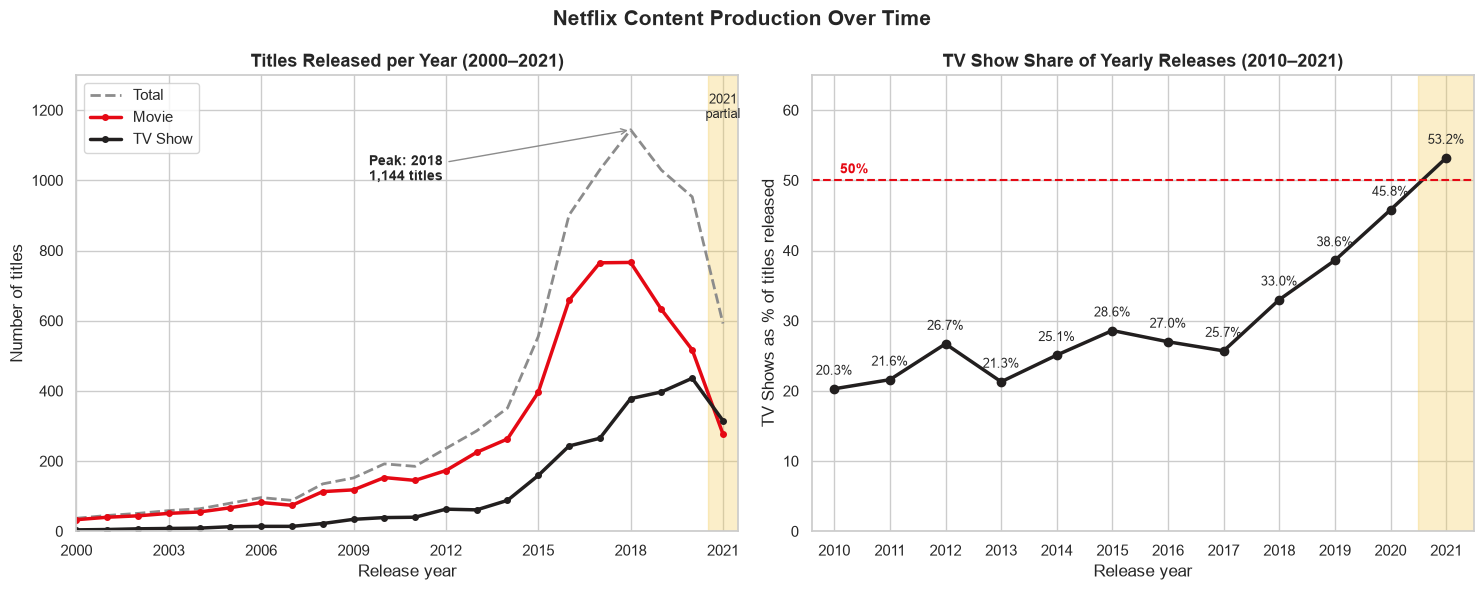

In [4]:
sns.set_theme(style="whitegrid")
red, black, grey = "#E50914", "#221F1F", "#8C8C8C"
plot_df = yearly.loc[2000:2021]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Chart 1 releases per year
ax = axes[0]
ax.plot(plot_df.index, plot_df["Total"], color=grey, linewidth=2, linestyle="--", label="Total")
ax.plot(plot_df.index, plot_df["Movie"], color=red, linewidth=2.5, marker="o", markersize=4, label="Movie")
ax.plot(plot_df.index, plot_df["TV Show"], color=black, linewidth=2.5, marker="o", markersize=4, label="TV Show")

ax.axvspan(2020.5, 2021.5, color="#F2C94C", alpha=0.3)           # partial year
ax.text(2021, 1250, "2021\npartial", ha="center", va="top", fontsize=9)
ax.annotate(f"Peak: 2018\n{yearly.loc[2018, 'Total']:,} titles",
            xy=(2018, yearly.loc[2018, "Total"]), xytext=(2009.5, 1000),
            arrowprops=dict(arrowstyle="->", color=grey), fontsize=10, fontweight="bold")

ax.set_title("Titles Released per Year (2000–2021)", fontsize=13, fontweight="bold")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of titles")
ax.set_xticks(range(2000, 2022, 3))
ax.set_xlim(2000, 2021.5)
ax.set_ylim(0, 1300)
ax.legend(loc="upper left")

#Chart 2 TV Show share of each year's releases
ax = axes[1]
ax.plot(trend.index, trend["TV_share_%"], color=black, linewidth=2.5, marker="o")
ax.axhline(50, color=red, linestyle="--", linewidth=1.5)
ax.text(2010.1, 51, "50%", color=red, fontsize=10, fontweight="bold")
ax.axvspan(2020.5, 2021.5, color="#F2C94C", alpha=0.3)

for x, v in trend["TV_share_%"].items():
    ax.text(x, v + 2, f"{v:.1f}%", ha="center", fontsize=9)

ax.set_title("TV Show Share of Yearly Releases (2010–2021)", fontsize=13, fontweight="bold")
ax.set_xlabel("Release year")
ax.set_ylabel("TV Shows as % of titles released")
ax.set_xticks(range(2010, 2022))
ax.set_xlim(2009.6, 2021.5)
ax.set_ylim(0, 65)

plt.suptitle("Netflix Content Production Over Time", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../screenshots/task4_trend_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5: Business interpretation

### What the data shows
| Period | Pattern |
|---|---|
| 2010 → 2018 | Titles released per year grew from 192 to **1,144** (about 6x). Growth was fastest in **2015–2016** (+58.1% and +62.3% YoY) |
| 2015 → 2018 | Total releases **doubled** (+106.1%) |
| 2018 | **Peak year**: 1,144 titles |
| 2018 → 2020 | Total fell **16.7%**, but Movies fell **32.5%** while TV Shows **grew 15.3%** |
| 2021 | TV Shows (315) outnumber Movies (277) for the first time |

**TV Show share of yearly releases:** 20.3% (2010) → 33.0% (2018) → 45.8% (2020) → 53.2% (2021, partial year).

### Business interpretation
- **The catalogue shifted from films to series.** Movie releases peaked in 2018 and then dropped sharply, while TV Show releases kept rising for two more years. This fits a strategy of favouring series, which keep subscribers engaged over weeks rather than one evening.
- **The mid-2010s were the expansion phase.** The jump in 2015–2016 matches the period when Netflix expanded internationally and invested heavily in content.
- **Older content is a small part of the catalogue.** Only 525 titles (6%) were released before 2000, and **84.8% were released in 2010 or later**, so the catalogue is dominated by recent content.

### Limitations
- **2021 is a partial year** (the data runs to September 2021), so the 2021 drop (−37.9%) and the 53.2% TV share should not be read as final.
- The dataset covers titles **available on Netflix**, not only titles Netflix produced. Release year reflects when a title came out, not when Netflix commissioned it, so the trend describes the catalogue rather than Netflix's production spending.
- The 2019–2021 decline in releases could reflect production disruption from COVID-19, or the way titles are added to the catalogue after release. This dataset cannot separate these explanations, so they are hypotheses to test, not conclusions.